
# Module 4 — Physics-Informed Symmetry: **Equivariant Graph Networks**
### TIFR ML School 2026 · *Sets, Graphs & Symmetry for High-Energy Physics*

Every model so far (DeepSets, ParticleNet, ParT) is built in only **one** symmetry: permutation. But physics has
*more*. A top quark is a top quark however the event is **rotated**, **translated**, or **Lorentz-boosted** — a
detector in a different orientation, or an observer in a different frame, must reach the same conclusion. This
module **bakes those symmetries into the network** as a hard inductive bias.

> **The one new ingredient: a group symmetry beyond permutation.** We constrain the *functions* the network can
> represent so that transforming the input by a group element $g$ transforms the output predictably
> ($f(\rho_g x)=\rho'_g f(x)$). The aggregation is still the Deep Sets pool — but now the messages may only be
> built from **group invariants**, and coordinate updates must transform **equivariantly**.

**What you will do, end-to-end:**
1. State the **equivariance condition**, *see* it on a 30-second toy, and build the two ingredients of the
   scalarization recipe — an invariant **scalar** and an equivariant **vector** — in a few lines each.
2. Implement an **E(n)-equivariant GNN (EGNN)**, **numerically verify** rotation+translation equivariance,
   *watch a vanilla GNN break it*, and **draw** the equivariant coordinate-update field.
3. Implement a **Lorentz-equivariant network (LorentzNet-lite)** from Minkowski invariants; see why the
   **metric** must change (Euclidean distance is not boost-invariant), and **verify that a Lorentz boost leaves
   its output unchanged** — uniformly over the whole group.
4. Run the headline experiment: **equivariant vs non-equivariant accuracy vs training-set size**; ask whether
   **data augmentation** can substitute for a built-in symmetry (it can't quite); and close with **equivariant
   regression** — a vector output a purely invariant net cannot produce.
5. Reach the frontier: build and verify the core of **L-GATr** (Lorentz-Equivariant Geometric Algebra Transformer) —
   a spacetime geometric algebra, its group action, equivariant linear maps *as the representation's commutant*, and
   **Lorentz-invariant attention** — then train it to tag jets.

**Dependencies:** `numpy torch torch_geometric matplotlib scikit-learn uproot awkward` (the L-GATr core in §8 needs
only `torch`).


## 1 · Symmetry, equivariance, invariance

A symmetry is a group $G$ acting on data. A map $f:X\to Y$ is **equivariant** if it commutes with the group:
$$ f(\rho_g\, x) = \rho'_g\, f(x)\quad\text{for all } g\in G, $$
where $\rho_g$ acts on the input and $\rho'_g$ on the output. **Invariance** is the special case where the output
does not transform at all ($\rho'_g=\mathrm{id}$) — what we want for a *classifier* (the label can't depend on the
frame). The pattern, exactly as in Module 1: stack **equivariant** layers, finish with an **invariant** readout.

Groups we care about in HEP:
- **Permutation** $S_N$ — particle ordering (Modules 1–3).
- **E(3)** — 3-D rotations + translations (calorimeter geometry; the EGNN below).
- **Lorentz $\mathrm{SO}^+(3,1)$** — boosts + rotations of 4-momenta (the deep one; LorentzNet below).

Why bother, when a big Transformer can *learn* approximate symmetry from data? Because building it in (i) guarantees
the symmetry **exactly**, for every input, and (ii) shrinks the hypothesis space, which typically means **better
generalization from less data** — the experiment in §5.

## 2 · Two ways to build an equivariant network

There are two dominant design philosophies — worth knowing which camp a paper is in:

- **Scalarization / invariant-feature.** Build all messages out of **invariants** of the group (Euclidean
  distances, Minkowski dot products), feed them through ordinary MLPs, and update coordinates by
  **invariant-weighted sums of equivariant vectors**. Simple, robust, no special algebra. → **EGNN** (E(n)),
  **LorentzNet**, **PELICAN** (permutation-equivariant + Lorentz). *This is what we implement.*
- **Steerable / equivariant-feature.** Carry features in **group representations** (vectors, tensors,
  spherical harmonics) and combine them with equivariant operations (tensor products, Clebsch–Gordan). More
  expressive, heavier machinery. → **LGN** (Lorentz Group Network), **Tensor-Field Networks**. *We discuss in §6.*

In [1]:

%matplotlib inline
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.utils import scatter
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

torch.manual_seed(0); np.random.seed(0)
device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print("device", device)

def mlp(i, o, h=64):
    return nn.Sequential(nn.Linear(i, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, o))

def fc_edge_index(batch):
    """Fully-connected edges WITHIN each graph (frame-independent, unlike a k-NN graph).
    Returns edge_index [2, E] = [source j, target i]."""
    same = batch.unsqueeze(0) == batch.unsqueeze(1)
    same.fill_diagonal_(False)
    idx = same.nonzero(as_tuple=False)          # pairs (i, j) that are connected
    return torch.stack([idx[:, 1], idx[:, 0]], dim=0)

def random_rotation(dim=3):
    """A uniformly-random proper rotation in `dim` dims (det +1), via QR of a Gaussian matrix."""
    A = torch.randn(dim, dim); Q, _ = torch.linalg.qr(A)
    if torch.det(Q) < 0: Q[:, 0] = -Q[:, 0]     # flip a column to force a proper rotation (det +1)
    return Q


device mps


## 2a · Invariance you can *see* — a 30-second experiment

Before any graphs, watch the payoff on the simplest possible problem. The target is **rotation-invariant**: is a
2-D point inside or outside a circle ($\|x\|^2>c$)? We fit two classifiers on the *same* data — a **naive** MLP on
the raw coordinates $x$, free to learn any orientation-dependent boundary, and an **invariant** MLP on the single
invariant $\|x\|^2$, for which $f(Rx)=f(x)$ **exactly**. We track, as the training set grows, both **test accuracy**
and an **invariance-violation**: the spread of a point's predicted probability as we spin it through rotations. A
truly invariant model has *zero* spread — at every size.

In [2]:
def ring(n):
    x = torch.randn(n, 2) * 1.2
    return x, ((x ** 2).sum(-1) > 1.8).long()          # label depends only on |x| -> rotation-invariant

class NaiveClf(nn.Module):                              # sees raw coordinates
    def __init__(self): super().__init__(); self.f = mlp(2, 2)
    def forward(self, x): return self.f(x)
class InvariantClf(nn.Module):                          # sees ONLY the invariant |x|^2  =>  f(Rx)=f(x) exactly
    def __init__(self): super().__init__(); self.f = mlp(1, 2)
    def forward(self, x): return self.f((x ** 2).sum(-1, keepdim=True))

def quickfit(m, X, Y, ep=400):
    opt = torch.optim.Adam(m.parameters(), 1e-2)
    for _ in range(ep): opt.zero_grad(); F.cross_entropy(m(X), Y).backward(); opt.step()
    return m

torch.manual_seed(1); Xte, Yte = ring(4000)
def accuracy(m):  return (m(Xte).argmax(-1) == Yte).float().mean().item()
def violation(m):                                       # std of P(class 1) across random rotations of each point
    ps = [F.softmax(m(Xte @ random_rotation(2).T), -1)[:, 1] for _ in range(16)]
    return torch.stack(ps).std(0).mean().item()

print(f"{'train size':>10} | {'naive acc':>9} {'violation':>10} | {'invariant acc':>13} {'violation':>10}")
for ntr in [60, 120, 400]:
    torch.manual_seed(0); Xtr, Ytr = ring(ntr)
    na = quickfit(NaiveClf(), Xtr, Ytr); iv = quickfit(InvariantClf(), Xtr, Ytr)
    print(f"{ntr:>10} | {accuracy(na):>9.3f} {violation(na):>10.4f} | {accuracy(iv):>13.3f} {violation(iv):>10.4f}")
print("\n=> the invariant model needs less data to reach high accuracy, and its violation is 0 at every size:")
print("   'built-in' is EXACT for every input; 'learned' is only approximate and wobbles under rotation.")

train size | naive acc  violation | invariant acc  violation


        60 |     0.937     0.0589 |         0.997     0.0000


       120 |     0.983     0.0197 |         0.999     0.0000


       400 |     0.989     0.0102 |         0.999     0.0000

=> the invariant model needs less data to reach high accuracy, and its violation is 0 at every size:
   'built-in' is EXACT for every input; 'learned' is only approximate and wobbles under rotation.


## 2b · The two ingredients on a toy: an invariant *scalar* and an equivariant *vector*

Scalarization needs exactly two building blocks, and each is one line. From a small 3-D point cloud we build an
**invariant scalar** — the sum of pairwise distances, unchanged by any rotation/translation ($s(Rx+t)=s(x)$), which
a *classifier* reads out — and an **equivariant vector** — a weight-and-sum of centroid-relative positions, which
*rotates with* the cloud ($v(Rx+t)=R\,v(x)$), which you need to *predict a direction/momentum*. These two behaviours
($\rho'_g=\mathrm{id}$ vs $\rho'_g=R$) are the whole game; every layer below is a fancier version of them.

In [3]:
torch.manual_seed(0)
pts = torch.randn(6, 3)

def invariant_scalar(x):                    # sum of pairwise Euclidean distances: E(3)-invariant
    return torch.cdist(x, x).sum()
def equivariant_vector(x):                  # weighted sum of centroid-relative positions: rotates as R v
    xc = x - x.mean(0)
    return (xc.norm(dim=1, keepdim=True) * xc).sum(0)

R, t = random_rotation(3), torch.randn(3)
xg = pts @ R.T + t                          # rho_g x  (rotate + translate)
print(f"invariant  scalar  |s(x) - s(Rx+t)|   = {(invariant_scalar(pts) - invariant_scalar(xg)).abs():.2e}   (rho'=id)")
print(f"equivariant vector |R v(x) - v(Rx+t)| = {(equivariant_vector(pts) @ R.T - equivariant_vector(xg)).norm():.2e}   (rho'=R)")

invariant  scalar  |s(x) - s(Rx+t)|   = 7.63e-06   (rho'=id)
equivariant vector |R v(x) - v(Rx+t)| = 1.73e-06   (rho'=R)


## 3 · EGNN — an E(n)-equivariant graph layer

EGNN (Satorras et al., 2021) keeps two things per node: invariant features $h_i$ and coordinates $x_i$. One layer:
$$
m_{ij}=\phi_e\big(h_i,h_j,\|x_i-x_j\|^2\big),\quad
h_i'=h_i+\phi_h\big(h_i,\textstyle\sum_j m_{ij}\big),\quad
x_i'=x_i+\tfrac{1}{|\mathcal N|}\textstyle\sum_j \phi_x(m_{ij})\,(x_i-x_j).
$$
Why it is **E(n)-equivariant**: messages depend on $x$ only through the distance $\|x_i-x_j\|^2$ (rotation- and
translation-invariant), so $h$ stays **invariant**; and $x_i'$ is $x_i$ plus an **invariant-weighted sum of the
vectors $x_i-x_j$**, so under a rotation $R$ and translation $t$ it transforms as $x_i'\mapsto Rx_i'+t$. We will
*check this numerically*.

In [4]:
class EGNNLayer(nn.Module):
    def __init__(self, hidden, c=0.1):
        super().__init__()
        self.phi_e = mlp(2 * hidden + 1, hidden)
        self.phi_h = mlp(2 * hidden, hidden)
        self.phi_x = nn.Linear(hidden, 1)
        self.c = c
    def forward(self, h, x, edge_index):
        src, dst = edge_index                                   # message j(src) -> i(dst)
        diff = x[dst] - x[src]
        d2 = (diff ** 2).sum(-1, keepdim=True)                  # invariant
        m = self.phi_e(torch.cat([h[dst], h[src], d2], dim=-1))
        h = h + self.phi_h(torch.cat([h, scatter(m, dst, dim=0, dim_size=h.size(0), reduce="sum")], dim=-1))
        x = x + self.c * scatter(self.phi_x(m) * diff, dst, dim=0, dim_size=x.size(0), reduce="mean")
        return h, x

### Verifying E(3) equivariance numerically

Apply a random rotation $R$ and translation $t$ to the input coordinates and pass them through the layer. The
output features $h'$ must be **unchanged** (invariant) and the output coordinates must satisfy
$x'(\text{transformed input}) = R\,x'(\text{input}) + t$ (equivariant). Both residuals should be ~0.

In [5]:

# random_rotation(dim) is now a shared helper (top of notebook). Test ONE EGNN layer under R, t in 3-D.
torch.manual_seed(1)
N = 12
h0 = torch.randn(N, 16); x0 = torch.randn(N, 3)
ei = fc_edge_index(torch.zeros(N, dtype=torch.long))
layer = EGNNLayer(16)

R, t = random_rotation(), torch.randn(3)
h1, x1 = layer(h0, x0, ei)                                      # original
h2, x2 = layer(h0, x0 @ R.T + t, ei)                            # transformed input
print(f"feature invariance   max|h'(x) - h'(Rx+t)|      = {(h1 - h2).abs().max().item():.2e}")
print(f"coord  equivariance  max|R x'(x)+t - x'(Rx+t)|  = {((x1 @ R.T + t) - x2).abs().max().item():.2e}")


feature invariance   max|h'(x) - h'(Rx+t)|      = 2.38e-07
coord  equivariance  max|R x'(x)+t - x'(Rx+t)|  = 7.15e-07


## 3a · A vanilla GNN is **not** equivariant — watch it break

Why insist that messages be built from invariants only? Because the obvious alternative — feed the raw coordinate
*components* $x_i-x_j$ into an MLP and let it emit a new coordinate vector — silently destroys the symmetry: an MLP
is not rotation-equivariant ($\mathrm{MLP}(Rv)\neq R\,\mathrm{MLP}(v)$). Here is that "naive GNN" beside EGNN, run
through the **same** E(3) test. EGNN's residuals sit at the float32 floor ($\sim\!10^{-7}$); the naive one is off by
a factor of $\sim\!10^5$.

In [6]:
class NaiveGNNLayer(nn.Module):
    """The tempting-but-wrong design: raw coordinate components go straight into the MLPs."""
    def __init__(self, hidden):
        super().__init__()
        self.phi_e = mlp(2 * hidden + 3, hidden)   # 3 = the RAW diff vector (not the invariant |diff|^2)
        self.phi_h = mlp(2 * hidden, hidden)
        self.phi_x = mlp(hidden, 3)                # emits an arbitrary 3-vector, NOT aligned to (x_i - x_j)
    def forward(self, h, x, edge_index):
        src, dst = edge_index
        diff = x[dst] - x[src]
        m = self.phi_e(torch.cat([h[dst], h[src], diff], dim=-1))                       # breaks invariance
        h = h + self.phi_h(torch.cat([h, scatter(m, dst, dim=0, dim_size=h.size(0), reduce="sum")], dim=-1))
        x = x + 0.1 * scatter(self.phi_x(m), dst, dim=0, dim_size=x.size(0), reduce="mean")  # breaks equivariance
        return h, x

torch.manual_seed(1)
Rr, tr = random_rotation(), torch.randn(3)
print(f"{'layer':>24} | {'feature |Δh|':>13} | {'coord |Δx|':>11}")
for name, lyr in [("EGNN (invariant msgs)", EGNNLayer(16)), ("naive GNN (raw coords)", NaiveGNNLayer(16))]:
    ha, xa = lyr(h0, x0, ei)                                    # h0, x0, ei from the E(3) test cell above
    hb, xb = lyr(h0, x0 @ Rr.T + tr, ei)
    print(f"{name:>24} | {(ha - hb).abs().max().item():>13.2e} | {((xa @ Rr.T + tr) - xb).abs().max().item():>11.2e}")
print("\n=> EGNN: equivariant to numerical precision. Naive GNN: the symmetry is simply gone.")

                   layer |  feature |Δh| |  coord |Δx|
   EGNN (invariant msgs) |      2.38e-07 |    3.58e-07
  naive GNN (raw coords) |      4.28e-02 |    6.95e-03

=> EGNN: equivariant to numerical precision. Naive GNN: the symmetry is simply gone.


## 3b · Equivariance **composes** — and a picture of the equivariant vector field

Two facts make EGNN usable as a *deep* network. (1) A stack of equivariant layers is still equivariant — the
property composes, so we can go deep without ever leaking the symmetry. (2) The coordinate update
$\Delta x_i=\sum_j\phi_x(m_{ij})(x_i-x_j)$ is a genuine **equivariant vector field**: rotate the input and the whole
field of update arrows rotates rigidly with it. We verify (1) on a 6-layer stack, then *draw* (2) in 2-D.

6-layer EGNN:  feature |Δh| = 2.38e-07   coord |Δx| = 4.77e-07


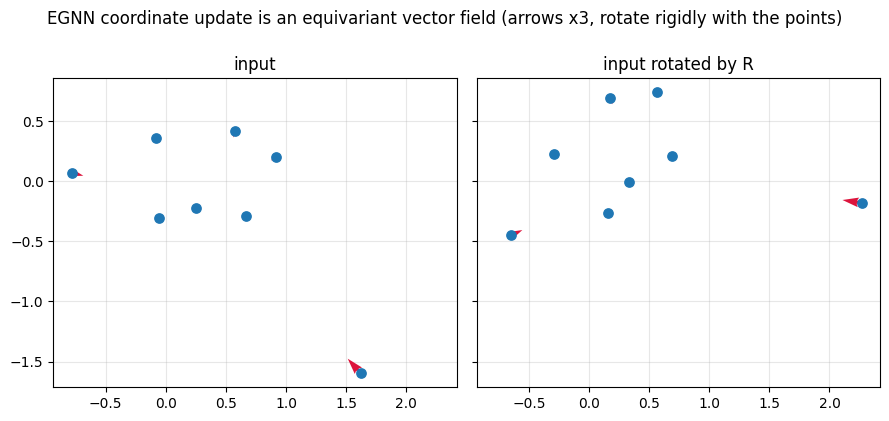

In [7]:
class EGNN(nn.Module):
    """A stack of EGNN layers with an input embedding. h -> invariant features, x -> equivariant coordinates."""
    def __init__(self, in_dim, hidden, layers):
        super().__init__()
        self.embed = nn.Linear(in_dim, hidden)
        self.layers = nn.ModuleList([EGNNLayer(hidden) for _ in range(layers)])
    def forward(self, h, x, edge_index):
        h = self.embed(h)
        for lyr in self.layers: h, x = lyr(h, x, edge_index)
        return h, x

# (1) equivariance of the whole 6-layer stack (reuse h0, x0, ei, Rr, tr from the cells above)
torch.manual_seed(2)
deep = EGNN(16, 32, layers=6)
ha, xa = deep(h0, x0, ei); hb, xb = deep(h0, x0 @ Rr.T + tr, ei)
print(f"6-layer EGNN:  feature |Δh| = {(ha - hb).abs().max().item():.2e}   "
      f"coord |Δx| = {((xa @ Rr.T + tr) - xb).abs().max().item():.2e}")

# (2) draw the update field Δx in 2-D, then rotate the input and redraw — the arrows rotate with it
torch.manual_seed(3)
P = torch.randn(8, 2); H = torch.randn(8, 16)
eip = fc_edge_index(torch.zeros(8, dtype=torch.long))
lyr2d = EGNNLayer(16)
Rot = random_rotation(2)
fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), sharex=True, sharey=True)
for ax, (title, Q) in zip(axes, [("input", torch.eye(2)), ("input rotated by R", Rot)]):
    Xin = P @ Q.T
    _, Xout = lyr2d(H, Xin, eip)
    d = (Xout - Xin).detach() * 3.0                             # x3 for visibility; directions are exact
    ax.scatter(*Xin.T.numpy(), s=45, zorder=3)
    ax.quiver(Xin[:, 0].numpy(), Xin[:, 1].numpy(), d[:, 0].numpy(), d[:, 1].numpy(),
              angles="xy", scale_units="xy", scale=1, color="crimson", width=0.008, zorder=2)
    ax.set_title(title); ax.set_aspect("equal"); ax.grid(alpha=0.3)
fig.suptitle("EGNN coordinate update is an equivariant vector field (arrows x3, rotate rigidly with the points)")
plt.tight_layout(); plt.show()

## 4 · LorentzNet-lite — a Lorentz-equivariant network

Now the symmetry that matters most for jets: the **Lorentz group**. The coordinate of each particle is its
**4-momentum** $x_i=(E,p_x,p_y,p_z)$, transforming as $x_i\mapsto \Lambda x_i$ under a boost/rotation $\Lambda$.
The Lorentz invariants of a pair are the **Minkowski** dot products (metric $\mathrm{diag}(+,-,-,-)$):
$$ \langle a,b\rangle = a_0 b_0 - \vec a\!\cdot\!\vec b, \qquad \|x_i-x_j\|^2=\langle x_i-x_j,\,x_i-x_j\rangle. $$
The **LGEB** block (Gong et al., 2022) mirrors EGNN but with Minkowski invariants and a stabilizing
$\psi(s)=\mathrm{sgn}(s)\log(|s|+1)$:
$$
m_{ij}=\phi_e\big(h_i,h_j,\psi(\|x_i-x_j\|^2),\psi(\langle x_i,x_j\rangle)\big),\quad
h_i'=h_i+\phi_h(h_i,\textstyle\sum_j m_{ij}),\quad
x_i'=x_i+c\textstyle\sum_j \phi_x(m_{ij})(x_i-x_j).
$$
Because messages use **only Lorentz invariants**, $h$ is Lorentz-**invariant** and $x$ transforms as a 4-vector.
The graph is **fully connected** (every pair) — the only frame-independent choice. The final readout pools the
invariant $h$, so the classifier output is **Lorentz-invariant by construction**.

In [8]:
def minkowski(a, b):
    """Minkowski inner product with metric (+,-,-,-).  a,b: (..., 4) -> (...,)"""
    return a[..., 0] * b[..., 0] - (a[..., 1:] * b[..., 1:]).sum(-1)

def psi(s):
    return torch.sign(s) * torch.log(torch.abs(s) + 1.0)

class LGEB(nn.Module):
    """Lorentz Group Equivariant Block (scalarization form).
    update_coords=True also evolves the 4-vectors equivariantly (as in EGNN). For a *classifier* we only need
    INVARIANCE, so we set it False and add a LayerNorm on the (invariant) features for stable training."""
    def __init__(self, hidden, c=0.01, update_coords=True):
        super().__init__()
        self.phi_e = mlp(2 * hidden + 2, hidden)
        self.phi_h = mlp(2 * hidden, hidden)
        self.phi_x = nn.Linear(hidden, 1)
        self.norm = nn.LayerNorm(hidden)
        self.c, self.update_coords = c, update_coords
    def forward(self, h, x, edge_index):
        src, dst = edge_index
        diff = x[dst] - x[src]
        norm2 = psi(minkowski(diff, diff)).unsqueeze(-1)             # invariant
        ip    = psi(minkowski(x[dst], x[src])).unsqueeze(-1)         # invariant
        m = self.phi_e(torch.cat([h[dst], h[src], norm2, ip], dim=-1))
        agg = scatter(m, dst, dim=0, dim_size=h.size(0), reduce="mean")
        h = self.norm(h + self.phi_h(torch.cat([h, agg], dim=-1)))   # LayerNorm preserves invariance (h is invariant)
        if self.update_coords:
            x = x + self.c * scatter(self.phi_x(m) * diff, dst, dim=0, dim_size=x.size(0), reduce="mean")
        return h, x

class LorentzNetLite(nn.Module):
    def __init__(self, hidden=64, n_layers=3, n_classes=2):
        super().__init__()
        self.embed = nn.Linear(2, hidden)                           # from two Lorentz scalars (see forward)
        # classifier needs only INVARIANCE -> disable the (equivariant) coordinate update for stability;
        # that update is exactly EGNN's and is needed only for equivariant *outputs* (Exercise 5).
        self.blocks = nn.ModuleList([LGEB(hidden, update_coords=False) for _ in range(n_layers)])
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.SiLU(),
                                  nn.Linear(hidden, n_classes))
    def forward(self, data):
        x, batch = data.pos, data.batch
        # invariant per-particle init: its mass^2 and its Minkowski product with the JET 4-momentum
        # (P_jet = sum of 4-momenta transforms as a 4-vector, so <p_i, P_jet> is Lorentz-invariant).
        p_jet = global_add_pool(x, batch)[batch]
        h = self.embed(torch.stack([psi(minkowski(x, x)), psi(minkowski(x, p_jet))], dim=-1))
        edge_index = fc_edge_index(batch)
        for blk in self.blocks:
            h, x = blk(h, x, edge_index)
        return self.head(global_mean_pool(h, batch))                # invariant readout

## 4a · Lorentz transformations in code (and a metric sanity check)

To *test* Lorentz invariance we need Lorentz transforms to hit our jets with. A general (proper, orthochronous)
element is a **rotation** composed with a **boost** in some direction. Its defining property is that it preserves
the Minkowski metric $g=\mathrm{diag}(+,-,-,-)$: $\ \Lambda^{\mathsf T} g\,\Lambda = g$. We build the pieces,
assemble a random $\Lambda$, and confirm that identity numerically.

In [9]:
def rotation4(R3):                                  # embed a 3-D rotation into 4x4 (leaves the energy/time axis)
    L = torch.eye(4); L[1:, 1:] = R3; return L

def boost_matrix(beta):                             # general boost with 3-velocity beta (|beta| < 1)
    beta = torch.as_tensor(beta, dtype=torch.float32); b2 = (beta * beta).sum()
    gamma = 1.0 / torch.sqrt(1 - b2); L = torch.eye(4)
    L[0, 0] = gamma; L[0, 1:] = gamma * beta; L[1:, 0] = gamma * beta
    L[1:, 1:] = torch.eye(3) + (gamma - 1) * torch.outer(beta, beta) / b2
    return L

def boost_z(xi):                                    # boost along z with rapidity xi (used throughout below)
    c, s = math.cosh(xi), math.sinh(xi); L = torch.eye(4)
    L[0, 0] = c; L[0, 3] = s; L[3, 0] = s; L[3, 3] = c
    return L

def random_lorentz(max_beta=0.8):                   # random rotation * boost * rotation
    b = torch.randn(3); b = b / b.norm() * (torch.rand(1) * max_beta)
    return rotation4(random_rotation()) @ boost_matrix(b) @ rotation4(random_rotation())

g = torch.diag(torch.tensor([1., -1., -1., -1.]))
L = random_lorentz()
print(f"random Lorentz Λ preserves the metric:  max|ΛᵀgΛ - g| = {(L.T @ g @ L - g).abs().max().item():.2e}")
print(f"boost_z(0.4) matches the general boost:  {(boost_z(0.4) - boost_matrix([0, 0, math.tanh(0.4)])).abs().max().item():.2e}")

random Lorentz Λ preserves the metric:  max|ΛᵀgΛ - g| = 4.77e-07
boost_z(0.4) matches the general boost:  1.19e-07


## 4b · Why the **Minkowski** metric? Euclidean distance is not boost-invariant

EGNN's messages used the Euclidean $\|x_i-x_j\|^2$. For 4-momenta that is the *wrong* invariant: a Lorentz boost
mixes energy and momentum, so the naive squared distance $\sum_\mu(\Delta p_\mu)^2$ **changes**. The quantity that
stays fixed is the **Minkowski** norm $\langle\Delta p,\Delta p\rangle=\Delta E^2-\Delta\vec p^{\,2}$. Below we
boost five particles and print both — Euclidean moves, Minkowski does not. That single fact is *why* LorentzNet
swaps the metric.

In [10]:
torch.manual_seed(0)
p = torch.randn(5, 4)
p[:, 0] = p[:, 1:].norm(dim=1) + torch.rand(5) + 0.5          # give each a physical energy E > |p| (timelike)
pb = p @ boost_z(0.6).T                                       # boost the whole set along z
d, db = p[0:1] - p, pb[0:1] - pb                              # separations from particle 0, before/after boost
fmt = lambda v: "[" + ", ".join(f"{x:6.2f}" for x in v) + "]"
print("Euclidean  Σ(Δp)²   before boost:", fmt((d ** 2).sum(-1).tolist()))
print("Euclidean  Σ(Δp)²   after  boost:", fmt((db ** 2).sum(-1).tolist()), "  <- changed")
print("Minkowski ⟨Δp,Δp⟩   before boost:", fmt(minkowski(d, d).tolist()))
print("Minkowski ⟨Δp,Δp⟩   after  boost:", fmt(minkowski(db, db).tolist()), "  <- invariant")

Euclidean  Σ(Δp)²   before boost: [  0.00,   9.04,   4.89,  10.81,  13.18]
Euclidean  Σ(Δp)²   after  boost: [  0.00,  29.41,   7.28,  10.72,  17.14]   <- changed
Minkowski ⟨Δp,Δp⟩   before boost: [  0.00,  -1.76,  -3.81,  -7.39,  -9.10]
Minkowski ⟨Δp,Δp⟩   after  boost: [  0.00,  -1.76,  -3.81,  -7.39,  -9.10]   <- invariant


## 5 · Data: each jet as a set of 4-momenta

For a clean Lorentz demonstration we use the particles' **4-momenta** directly. We keep the **leading $N$
particles by energy** per jet (so fully-connected graphs stay cheap) and scale momenta to $\mathcal O(1)$ (a
Lorentz-*scalar* rescaling — it does not break the symmetry, it just helps float32 conditioning). Each PyG `Data`
stores `pos = x = ` the (scaled) 4-vectors; the equivariant model reads `pos`, the non-equivariant baseline reads
`x`.

In [11]:
import os, uproot, awkward as ak

CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("Place JetClass_example_100k.root in ../data/.")

NPART, N_PER_CLS, SCALE = 24, 8000, 0.01
tree = uproot.open(root_path)["tree"]
br = tree.arrays(["part_px","part_py","part_pz","part_energy","label_QCD","label_Tbqq","label_Tbl"])
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)
sel = np.concatenate([np.where(is_qcd)[0][:N_PER_CLS], np.where(is_top)[0][:N_PER_CLS]])
labels = np.concatenate([np.zeros(N_PER_CLS), np.ones(N_PER_CLS)]).astype(np.int64)

px,py,pz,e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
order = ak.argsort(e, axis=1, ascending=False)                  # leading particles by energy
def topN(a): return ak.to_numpy(ak.fill_none(ak.pad_none(a[order], NPART, clip=True), 0.0))
P4 = (np.stack([topN(e), topN(px), topN(py), topN(pz)], axis=-1).astype(np.float32)) * SCALE   # (Njet,N,4)
counts = np.minimum(ak.to_numpy(ak.num(e, axis=1)), NPART)

data_list = []
for i in range(len(labels)):
    n = int(counts[i])
    if n < 2: continue
    fm = torch.from_numpy(P4[i, :n])
    data_list.append(Data(x=fm, pos=fm, y=torch.tensor([int(labels[i])], dtype=torch.long)))

import random
random.seed(0); random.shuffle(data_list)
test_set = data_list[-3000:]
pool     = data_list[:-3000]
test_loader = DataLoader(test_set, batch_size=128)
print(f"{len(data_list)} jets | pool {len(pool)} | test {len(test_set)} | each jet <= {NPART} particles (4-vectors)")

16000 jets | pool 13000 | test 3000 | each jet <= 24 particles (4-vectors)


## 5a · The physics the network sees — and why the $\psi$ squashing

Two quick looks at the actual inputs. **First**, the most famous Lorentz invariant of a jet, its **invariant mass**
$M=\sqrt{\langle P,P\rangle}$ with $P=\sum_i p_i$: a top jet contains the decay of a heavy particle, so its mass
piles up at $\mathcal O(100\,\text{GeV})$, while a QCD jet is soft and light — the classes separate on this one
invariant alone, exactly the signal LorentzNet is built to exploit. **Second**, the raw pairwise invariants
$\langle p_i,p_j\rangle$ span *many orders of magnitude* (hard leading pairs vs soft radiation), which float32 and
MLPs both hate — that is what $\psi(s)=\mathrm{sgn}(s)\log(|s|+1)$ is for: compress the dynamic range while keeping
sign and monotonicity.

jet mass median:   QCD  57.3 GeV    top 115.9 GeV
raw |<p_i,p_j>| spans ~8 decades across the bulk (1-99%), wider in the tails  ->  psi maps everything into [-0.00, 1.03]


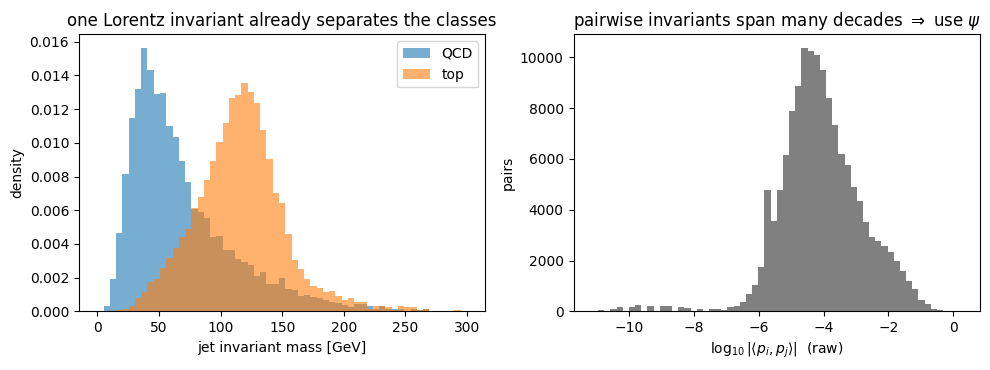

In [12]:
# jet invariant mass (a Lorentz scalar), in GeV -- undo the O(1) rescaling for a physical x-axis
P = P4.sum(axis=1) / SCALE                                   # jet 4-momentum = sum over constituents (zeros pad)
m2 = P[:, 0] ** 2 - (P[:, 1:] ** 2).sum(-1)
mjet = np.sqrt(np.clip(m2, 0, None))
print(f"jet mass median:   QCD {np.median(mjet[labels==0]):5.1f} GeV    top {np.median(mjet[labels==1]):5.1f} GeV")

# dynamic range of the pairwise Minkowski invariants (top jets), raw vs psi-squashed
vals = []
for i in np.where(labels == 1)[0][:300]:
    n = int(counts[i]); fm = torch.from_numpy(P4[i, :n])
    vals.append(minkowski(fm.unsqueeze(0), fm.unsqueeze(1)).flatten())
vals = torch.cat(vals); a = vals.abs(); a = a[a > 0]
q01, q99 = torch.quantile(a, 0.01).item(), torch.quantile(a, 0.99).item()
print(f"raw |<p_i,p_j>| spans ~{math.log10(q99 / q01):.0f} decades across the bulk (1-99%), wider in the tails "
      f" ->  psi maps everything into [{psi(vals).min().item():.2f}, {psi(vals).max().item():.2f}]")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].hist(mjet[labels == 0], bins=np.linspace(0, 300, 60), alpha=0.6, density=True, label="QCD")
ax[0].hist(mjet[labels == 1], bins=np.linspace(0, 300, 60), alpha=0.6, density=True, label="top")
ax[0].set_xlabel("jet invariant mass [GeV]"); ax[0].set_ylabel("density"); ax[0].legend()
ax[0].set_title("one Lorentz invariant already separates the classes")
ax[1].hist(np.log10(a.numpy()), bins=60, color="gray")
ax[1].set_xlabel(r"$\log_{10}|\langle p_i,p_j\rangle|$  (raw)"); ax[1].set_ylabel("pairs")
ax[1].set_title(r"pairwise invariants span many decades $\Rightarrow$ use $\psi$")
plt.tight_layout(); plt.show()

### The two contestants we will race

The experiment in §6 pits two permutation-invariant models against each other. One — **LorentzNet-lite** (above) —
*also* has Lorentz symmetry built in. The other — a plain **DeepSets** on the raw 4-vector components — does not.
Same pooling, same readout capacity; the *only* difference is the physical inductive bias. Here is the baseline.

In [13]:
class DeepSetsBaseline(nn.Module):
    """Permutation-invariant but NOT Lorentz-equivariant: a plain DeepSet on raw 4-vector components."""
    def __init__(self, hidden=64, n_classes=2):
        super().__init__()
        self.phi = mlp(4, hidden)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, hidden), nn.SiLU(),
                                  nn.Linear(hidden, n_classes))
    def forward(self, data):
        return self.head(global_mean_pool(self.phi(data.x), data.batch))

## 5b · Verifying Lorentz invariance (the headline guarantee)

We take a batch of jets, apply a **Lorentz boost** $\Lambda$ along $z$ to every 4-momentum, and check that
LorentzNet-lite's output is **unchanged**. This holds for an *untrained* network — it is **architectural**, not
learned. (We also confirm the boost preserves each particle's invariant mass.)

In [14]:

# boost_z / random_lorentz live in §4a. Verify invariance on a real batch of jets (untrained net).
lnet_demo = LorentzNetLite(hidden=64, n_layers=3).to(device)
lnet_demo.eval()
data = next(iter(test_loader)).to(device)
L = boost_z(0.4).to(device)
with torch.no_grad():
    out_lab = lnet_demo(data)
    boosted = data.clone(); boosted.pos = data.pos @ L.T          # Lambda x for every particle
    out_boost = lnet_demo(boosted)
mass_change = (minkowski(data.pos, data.pos) - minkowski(boosted.pos, boosted.pos)).abs().max().item()
print(f"invariant mass^2 change under boost : {mass_change:.2e}   (boost is a valid Lorentz transform)")
print(f"max |f(jet) - f(boosted jet)|       : {(out_lab - out_boost).abs().max().item():.2e}   "
      f"(~0 => Lorentz-invariant BY CONSTRUCTION, even untrained)")


invariant mass^2 change under boost : 3.05e-05   (boost is a valid Lorentz transform)
max |f(jet) - f(boosted jet)|       : 9.98e-07   (~0 => Lorentz-invariant BY CONSTRUCTION, even untrained)


## 5c · Scanning the group: output drift vs boost strength

§5b checked a single boost. Now sweep the rapidity $\xi$ and plot how far each model's output moves,
$\max|f(\Lambda x)-f(x)|$. LorentzNet stays pinned at the float32 floor for *every* boost — the guarantee is
uniform over the whole group. The DeepSets baseline drifts further and further: it has no reason to be invariant,
and no amount of training fixes a symmetry the architecture does not respect. (Both models here are **untrained** —
this is about the function class, not the fit.)

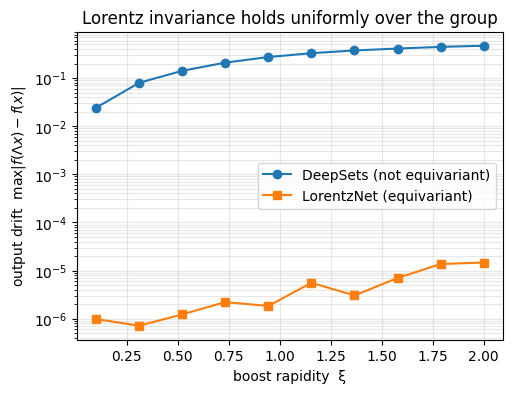

LorentzNet drift stays ~3e-06 for all ξ;  DeepSets grows to 0.47.


In [15]:
lnet_s = LorentzNetLite().to(device).eval()
dset_s = DeepSetsBaseline().to(device).eval()
batch0 = next(iter(test_loader)).to(device)

@torch.no_grad()
def output_drift(model, data, L):
    base = model(data)
    b = data.clone(); b.pos = data.pos @ L.T; b.x = data.x @ L.T          # boost every particle's 4-vector
    return (model(b) - base).abs().max().item()

xis = np.linspace(0.1, 2.0, 10)
drift_eq = [output_drift(lnet_s, batch0, boost_z(x).to(device)) for x in xis]
drift_ne = [output_drift(dset_s, batch0, boost_z(x).to(device)) for x in xis]

plt.figure(figsize=(5.5, 4))
plt.plot(xis, drift_ne, "o-", label="DeepSets (not equivariant)")
plt.plot(xis, drift_eq, "s-", label="LorentzNet (equivariant)")
plt.yscale("log"); plt.xlabel("boost rapidity  ξ"); plt.ylabel(r"output drift  max$|f(\Lambda x)-f(x)|$")
plt.title("Lorentz invariance holds uniformly over the group")
plt.grid(alpha=0.3, which="both"); plt.legend(); plt.show()
print(f"LorentzNet drift stays ~{np.median(drift_eq):.0e} for all ξ;  DeepSets grows to {drift_ne[-1]:.2f}.")

## 6 · The experiment: does equivariance buy data efficiency?

The central claim of equivariant ML: a correct physical inductive bias **reaches a given accuracy with far less
data**. We test it directly. Same jets, same invariant readout, two models:
- **LorentzNet-lite** — Lorentz-invariant, message-passing on Minkowski invariants, and
- **DeepSets baseline** — a permutation-invariant but *not* Lorentz-aware DeepSet on the raw 4-vector components.

We train both at several training-set sizes and plot test AUC vs size. Read the plot **horizontally**: how much
data does each model need to reach a given accuracy? The expectation is a large **leftward shift** for the
equivariant model — it should match the baseline's best with a fraction of the data. (The baseline here is
deliberately simple and plateaus; whether a *high-capacity* non-equivariant model eventually catches up is
Exercise 6.)

In [16]:

from sklearn.metrics import roc_auc_score
# DeepSetsBaseline (our non-equivariant contestant) was defined back in §5. Here: eval + train helpers.

@torch.no_grad()
def auc_of(model, loader):
    model.eval(); ys, ps = [], []
    for d in loader:
        d = d.to(device); ys.append(d.y.cpu()); ps.append(F.softmax(model(d), -1)[:, 1].cpu())
    return roc_auc_score(torch.cat(ys).numpy(), torch.cat(ps).numpy())

def train(model, loader, epochs=30, lr=1e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for _ in range(epochs):
        model.train()
        for d in loader:
            d = d.to(device)
            loss = F.cross_entropy(model(d), d.y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return model


train size   500:  LorentzNet AUC 0.810±0.007   |   DeepSets AUC 0.654±0.000   (equivariance gain +0.156)


train size  2000:  LorentzNet AUC 0.905±0.005   |   DeepSets AUC 0.695±0.000   (equivariance gain +0.210)


train size  6000:  LorentzNet AUC 0.963±0.001   |   DeepSets AUC 0.715±0.001   (equivariance gain +0.247)

=> data efficiency: LorentzNet on 500 jets (AUC 0.810) already beats DeepSets on 6000 jets (AUC 0.715) -- an order of magnitude less data.


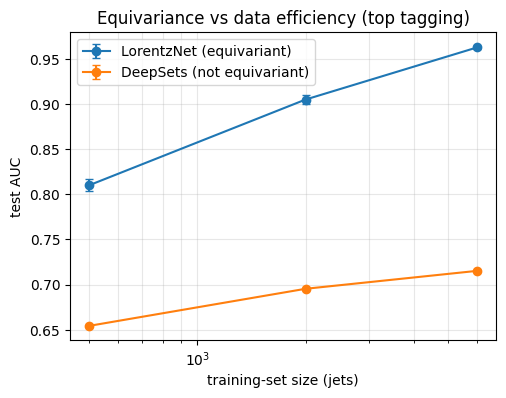

In [17]:
train_sizes, seeds = [500, 2000, 6000], [0, 1]            # average over 2 seeds to de-noise small-data runs
results = {"LorentzNet (equivariant)": [], "DeepSets (not equivariant)": []}

for ntr in train_sizes:
    tr_loader = DataLoader(pool[:ntr], batch_size=128, shuffle=True)
    eq, ne = [], []
    for s in seeds:
        torch.manual_seed(s)
        eq.append(auc_of(train(LorentzNetLite(hidden=64, n_layers=3).to(device), tr_loader), test_loader))
        torch.manual_seed(s)
        ne.append(auc_of(train(DeepSetsBaseline(hidden=64).to(device), tr_loader), test_loader))
    results["LorentzNet (equivariant)"].append((float(np.mean(eq)), float(np.std(eq))))
    results["DeepSets (not equivariant)"].append((float(np.mean(ne)), float(np.std(ne))))
    print(f"train size {ntr:5d}:  LorentzNet AUC {np.mean(eq):.3f}±{np.std(eq):.3f}   |   "
          f"DeepSets AUC {np.mean(ne):.3f}±{np.std(ne):.3f}   (equivariance gain {np.mean(eq)-np.mean(ne):+.3f})")

eq0 = results["LorentzNet (equivariant)"][0][0]; ne_big = results["DeepSets (not equivariant)"][-1][0]
print(f"\n=> data efficiency: LorentzNet on {train_sizes[0]} jets (AUC {eq0:.3f}) already beats "
      f"DeepSets on {train_sizes[-1]} jets (AUC {ne_big:.3f}) -- an order of magnitude less data.")

plt.figure(figsize=(5.5, 4))
for name, vals in results.items():
    mu, sd = [v[0] for v in vals], [v[1] for v in vals]
    plt.errorbar(train_sizes, mu, yerr=sd, marker="o", capsize=3, label=name)
plt.xscale("log"); plt.xlabel("training-set size (jets)"); plt.ylabel("test AUC")
plt.title("Equivariance vs data efficiency (top tagging)")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

## 6a · "Why not just augment?" — the honest comparison

A fair objection: instead of *building in* Lorentz symmetry, why not keep the flexible DeepSets and **augment** the
training data with random Lorentz transforms, letting it *learn* the invariance? We try exactly that — the same
baseline, but each batch is hit with a fresh random $\Lambda$ during training. At best this only *approximates*
invariance — it spends capacity and data to learn what the equivariant net gets for free, never becomes exact, and
still trails the built-in model by a wide margin. Building the symmetry in is strictly the better deal.

In [18]:
def train_augmented(model, loader, epochs=30, lr=1e-3):
    """Same as train(), but boost every batch by a fresh random Lorentz transform (data augmentation)."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for _ in range(epochs):
        model.train()
        for d in loader:
            d = d.to(device); Laug = random_lorentz().to(device)
            d = d.clone(); d.x = d.x @ Laug.T; d.pos = d.pos @ Laug.T
            loss = F.cross_entropy(model(d), d.y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return model

print(f"{'train size':>10} | {'DeepSets':>9} | {'DeepSets+aug':>12} | {'LorentzNet':>11}")
for ntr in [500, 2000]:
    ld = DataLoader(pool[:ntr], batch_size=128, shuffle=True)
    torch.manual_seed(0); a_plain = auc_of(train(DeepSetsBaseline().to(device), ld), test_loader)
    torch.manual_seed(0); a_aug   = auc_of(train_augmented(DeepSetsBaseline().to(device), ld), test_loader)
    torch.manual_seed(0); a_eq    = auc_of(train(LorentzNetLite().to(device), ld), test_loader)
    print(f"{ntr:>10} | {a_plain:>9.3f} | {a_aug:>12.3f} | {a_eq:>11.3f}")
    gap = a_eq - max(a_plain, a_aug)
print(f"\n=> even with augmentation, the built-in model leads by ~{gap:.2f} AUC at {ntr} jets: augmentation only")
print("   approximates the symmetry (and never reaches it exactly); building it in wins, on less data.")

train size |  DeepSets | DeepSets+aug |  LorentzNet


       500 |     0.655 |        0.657 |       0.804


      2000 |     0.696 |        0.706 |       0.900

=> even with augmentation, the built-in model leads by ~0.19 AUC at 2000 jets: augmentation only
   approximates the symmetry (and never reaches it exactly); building it in wins, on less data.


## 6b · Equivariant outputs: a vector an invariant net *cannot* produce

Classification only needs invariance, so LorentzNet threw its coordinate branch away. But that branch is the whole
point of EGNN/LGEB when the *target* transforms — regressing a jet axis, a missing-momentum vector, a pull angle.
Here is a clean E(3) demonstration: predict a target **3-vector** $t$ that rotates with the input cloud. The EGNN
reads it out as (invariant weight)$\times$(equivariant position) and nails it — and its prediction rotates
correctly, to numerical precision. An "invariant" net that emits three numbers from pooled invariants
*structurally* cannot: its output can't rotate, so it can neither fit nor stay equivariant.

In [19]:
# synthetic point clouds; target t(cloud) = Σ_i w(d_i)(x_i - x̄) is an equivariant 3-vector
def make_cloud(n=10):
    x = torch.randn(n, 3); xc = x - x.mean(0)
    return x, (torch.exp(-xc.norm(dim=1, keepdim=True)) * xc).sum(0)
def batch_clouds(B, n=10):
    xs, ts, b = [], [], []
    for i in range(B):
        x, tt = make_cloud(n); xs.append(x); ts.append(tt); b += [i] * n
    return torch.cat(xs), torch.stack(ts), torch.tensor(b)

class EGNNVector(nn.Module):        # equivariant readout: invariant weights times centroid-relative positions
    def __init__(self, hidden=32, layers=4):
        super().__init__()
        self.h0 = nn.Parameter(torch.randn(hidden) * 0.1)
        self.net = EGNN(hidden, hidden, layers)                 # the stack from §3b
        self.w = nn.Linear(hidden, 1)
    def forward(self, x, batch):
        h = self.h0.expand(x.size(0), -1).contiguous()
        ho, _ = self.net(h, x, fc_edge_index(batch))
        xc = x - scatter(x, batch, dim=0, reduce="mean")[batch]
        return scatter(self.w(ho) * xc, batch, dim=0, reduce="mean")

class InvariantVector(nn.Module):   # tries to emit a 3-vector from pooled invariants -> can't be equivariant
    def __init__(self, hidden=32):
        super().__init__(); self.phi = mlp(1, hidden); self.head = mlp(hidden, 3)
    def forward(self, x, batch):
        xc = x - scatter(x, batch, dim=0, reduce="mean")[batch]
        g = scatter(self.phi(xc.norm(dim=1, keepdim=True)), batch, dim=0, reduce="mean")
        return self.head(g)

torch.manual_seed(3)
Xtr, Ttr, Btr = batch_clouds(256); Xte, Tte, Bte = batch_clouds(128)
trivial = Tte.var(0).mean().item()                              # MSE of just predicting the mean vector
def fit_reg(m, ep=500):
    opt = torch.optim.Adam(m.parameters(), 3e-3)
    for _ in range(ep): opt.zero_grad(); F.mse_loss(m(Xtr, Btr), Ttr).backward(); opt.step()
    return m

print(f"{'model':>18} | {'test MSE':>9} | {'vs trivial':>10} | {'equivariance |Rp - p(Rx)|':>26}")
for name, M in [("EGNN vector", EGNNVector()), ("invariant vector", InvariantVector())]:
    m = fit_reg(M)
    with torch.no_grad():
        pred = m(Xte, Bte); mse = F.mse_loss(pred, Tte).item()
        Rr3 = random_rotation(3); eqv = (pred @ Rr3.T - m(Xte @ Rr3.T, Bte)).abs().max().item()
    print(f"{name:>18} | {mse:>9.4f} | {mse/trivial:>9.0%} | {eqv:>26.2e}")
print("\n=> the EGNN fits the vector target and is exactly equivariant; the invariant net can do neither.")

             model |  test MSE | vs trivial |  equivariance |Rp - p(Rx)|


       EGNN vector |    0.0000 |        0% |                   8.05e-07


  invariant vector |    0.1241 |      129% |                   2.18e+00

=> the EGNN fits the vector target and is exactly equivariant; the invariant net can do neither.



## 7 · The landscape: PELICAN, LGN, and steerable nets

LorentzNet-lite is the *scalarization* recipe. The field has two more landmarks worth knowing:
- **PELICAN** (Bogatskiy et al., 2022) — permutation-equivariant + Lorentz, built from the **complete set of
  Lorentz invariants** ($\langle p_i,p_j\rangle$ for all pairs) and permutation-equivariant aggregators. Remarkably
  accurate and parameter-efficient; arguably the cleanest realization of "use all the invariants".
- **LGN** (Lorentz Group Network) and **Tensor-Field Networks** — the *steerable* route: features live in Lorentz/
  rotation **representations** and interact via tensor products / Clebsch–Gordan coefficients. Maximally
  expressive, but heavier to implement and train.

Trade-off to remember: scalarization is simple and strong (and usually enough for tagging); steerable is needed
when you must output **equivariant** quantities (e.g. regress a 4-vector), not just an invariant label. The steerable
route's current state of the art is **L-GATr** — a Lorentz-equivariant *Transformer* on the spacetime **geometric
algebra**. We build and verify its core next.


## 8 · The frontier: **L-GATr**, a Lorentz-equivariant geometric-algebra transformer

§7 named two routes. LorentzNet took the *scalarization* route; the *steerable* route carries features in genuine
group representations, and its state of the art is **L-GATr** (Spinner, Bresó, de Haan, Plehn, Thaler & Brehmer,
[arXiv:2405.14806](https://arxiv.org/abs/2405.14806); code: [`heidelberg-hepml/lgatr`](https://github.com/heidelberg-hepml/lgatr)):
a **Transformer** whose hidden states are **multivectors of the spacetime geometric (Clifford) algebra**
$\mathrm{Cl}(1,3)$, and whose every layer — linear, attention, MLP, normalization — is Lorentz-equivariant *by
construction*.

The idea in one line: **stop hand-picking invariants; carry the full geometric object and let only equivariant
operations touch it.** A single multivector packs a scalar, a 4-vector, a bivector (think field strength
$F^{\mu\nu}$), an axial-vector, and a pseudoscalar into one 16-dimensional object. Below we build the core from
scratch and *verify* — exactly as everywhere else in this module — that it respects the Lorentz group to
floating-point precision. (Ours is a faithful **minimal** core; §8f lists what the production model adds.)

### 8a · Spacetime geometric algebra $\mathrm{Cl}(1,3)$ from scratch

Build four basis vectors $e_0,e_1,e_2,e_3$ obeying $e_\mu e_\nu + e_\nu e_\mu = 2\,g_{\mu\nu}$ with
$g=\mathrm{diag}(+,-,-,-)$ (so $e_0^2=+1$, $e_i^2=-1$). Products of distinct basis vectors are **blades**, graded by
how many vectors they contain:

| grade | blades | dim | physics |
|---|---|---|---|
| 0 | $1$ | 1 | scalar |
| 1 | $e_\mu$ | 4 | **4-vector** (momentum) |
| 2 | $e_\mu e_\nu$ | 6 | bivector / antisymmetric tensor ($F^{\mu\nu}$) |
| 3 | $e_\mu e_\nu e_\rho$ | 4 | axial 4-vector |
| 4 | $e_0e_1e_2e_3$ | 1 | pseudoscalar |

A multivector is thus a **16-dimensional** vector. The **geometric product** multiplies blades (distinct vectors
anticommute, repeated ones contract with the metric); the **reversal** $\tilde x$ flips blade order; the **invariant
inner product** $\langle x,y\rangle=\langle\tilde x\,y\rangle_0$ is the scalar part of $\tilde x y$. We build all
three from the blade rules and check three things: the inner-product weights reproduce the L-GATr repo's array, the
Clifford relation holds, and — the bridge back to §4 — a 4-vector embedded at grade 1 has GA inner product equal to
its **Minkowski** norm.

In [20]:
import itertools
GMET = [1.0, -1.0, -1.0, -1.0]                                      # metric of e0..e3 (e0 timelike)
BLADES = [c for g in range(5) for c in itertools.combinations(range(4), g)]     # 16 blades, grade-then-lex order
BLADE_MASK = [sum(1 << i for i in b) for b in BLADES]
BIDX = {m: k for k, m in enumerate(BLADE_MASK)}
GRADE = torch.tensor([len(b) for b in BLADES])

def _popcount(x): return bin(x).count("1")
def _blade_mul(A, B):                                               # geometric product of two basis blades (bitmasks)
    swaps = sum(_popcount(A & ~((1 << (j + 1)) - 1) & 0xF) for j in range(4) if (B >> j) & 1)
    sign = -1.0 if swaps & 1 else 1.0                              # sign from reordering into canonical order
    metric = 1.0
    for j in range(4):
        if ((A & B) >> j) & 1: metric *= GMET[j]                   # contract shared vectors with the metric
    return sign * metric, A ^ B                                    # coefficient, resulting blade (symmetric diff)

GP = torch.zeros(16, 16, 16)                                        # geometric-product structure constants
for i, Ai in enumerate(BLADE_MASK):
    for j, Aj in enumerate(BLADE_MASK):
        coeff, res = _blade_mul(Ai, Aj); GP[i, j, BIDX[res]] += coeff
REV = torch.tensor([(-1.0) ** (g * (g - 1) // 2) for g in GRADE.tolist()])       # reversal signs per blade
IP = REV * GP[torch.arange(16), torch.arange(16), 0]               # inner-product factors <~b_i b_i>_0

def geo_prod(x, y): return torch.einsum("...i,...j,ijk->...k", x, y, GP)
def reverse(x):     return x * REV
def ga_inner(x, y): return (x * IP * y).sum(-1)                     # <x,y> = <~x y>_0  (Lorentz-invariant)
def embed_vec(v):                                                  # 4-vector -> grade-1 multivector (blades e0..e3)
    mv = torch.zeros(*v.shape[:-1], 16, device=v.device); mv[..., 1:5] = v; return mv

_repo_ip = torch.tensor([1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1.])
print("inner-product factors match the L-GATr repo :", bool(torch.equal(IP, _repo_ip)))
E = [embed_vec(torch.eye(4)[k]) for k in range(4)]
cliff = torch.tensor([[(geo_prod(E[i], E[j]) + geo_prod(E[j], E[i]))[0] for j in range(4)] for i in range(4)])
print("Clifford relation max|{e_i,e_j} - 2 g_ij|    :", (cliff - 2 * torch.diag(torch.tensor(GMET))).abs().max().item())
vv = torch.randn(5, 4)
print("GA inner product == Minkowski   max|Δ|       :", (ga_inner(embed_vec(vv), embed_vec(vv)) - minkowski(vv, vv)).abs().max().item())

inner-product factors match the L-GATr repo : True
Clifford relation max|{e_i,e_j} - 2 g_ij|    : 0.0
GA inner product == Minkowski   max|Δ|       : 2.384185791015625e-07


### 8b · How the Lorentz group acts on a multivector

A Lorentz transformation $\Lambda\in\mathrm{O}(1,3)$ sends a 4-vector to $\Lambda v$. It extends to the *whole*
algebra as the **outermorphism** $\rho(\Lambda)=\bigoplus_k \wedge^k\Lambda$: grade $k$ transforms by the $k$-th
exterior power (grade 0 trivially, grade 1 as $\Lambda$, grade 2 as the antisymmetric-tensor rep, grade 4 by
$\det\Lambda$). This is exactly the action L-GATr uses — the repo realizes the same map as the **Pin(1,3) versor
sandwich** $u\,x\,u^{-1}$. Because $\Lambda$ preserves the metric, $\rho(\Lambda)$ is an **automorphism of the
geometric product** and preserves the inner product — the two facts that make every layer below equivariant. We
verify all of it, for a proper $\Lambda$ *and* for parity.

In [21]:
PARITY = torch.diag(torch.tensor([1.0, -1.0, -1.0, -1.0]))         # spatial parity: det -1 (an improper Lorentz map)

def rho(Lam):                                                      # outermorphism: blade S -> blade T by a minor of Lam
    M = torch.zeros(16, 16)
    for a, T in enumerate(BLADES):
        for b, S in enumerate(BLADES):
            if len(T) == len(S):
                M[a, b] = 1.0 if len(T) == 0 else torch.det(Lam[list(T)][:, list(S)])
    return M

La, Lb = random_lorentz(), random_lorentz()
Ra, Rb = rho(La), rho(Lb)
a, b = torch.randn(16), torch.randn(16)
print(f"rho is a representation      |rho(LL')-rho(L)rho(L')| : {(rho(La @ Lb) - Ra @ Rb).abs().max().item():.2e}")
print(f"rho acts as Lambda on 4-vectors                       : {((Ra @ embed_vec(vv).T).T[:, 1:5] - vv @ La.T).abs().max().item():.2e}")
print(f"rho intertwines the geometric product (proper Lambda) : {(geo_prod(Ra @ a, Ra @ b) - Ra @ geo_prod(a, b)).abs().max().item():.2e}")
print(f"rho intertwines the geometric product (parity)        : {(geo_prod(rho(PARITY) @ a, rho(PARITY) @ b) - rho(PARITY) @ geo_prod(a, b)).abs().max().item():.2e}")
print(f"inner product is invariant   |<Ra,Rb> - <a,b>|        : {(ga_inner(Ra @ a, Ra @ b) - ga_inner(a, b)).abs().max().item():.2e}")

rho is a representation      |rho(LL')-rho(L)rho(L')| : 2.38e-07
rho acts as Lambda on 4-vectors                       : 1.19e-07
rho intertwines the geometric product (proper Lambda) : 1.43e-06
rho intertwines the geometric product (parity)        : 0.00e+00
inner product is invariant   |<Ra,Rb> - <a,b>|        : 8.34e-07


### 8c · Equivariant linear layers = the *commutant* of the representation

Which linear maps $W:\mathbb R^{16}\to\mathbb R^{16}$ are Lorentz-equivariant? Exactly those that **commute with the
representation**, $W\rho(\Lambda)=\rho(\Lambda)W$ for all $\Lambda$ (Schur's lemma). We needn't guess them — we
*compute* the commutant as the null space of $\{\rho(\Lambda)\otimes I-I\otimes\rho(\Lambda)^{\!\top}\}$.

The **dimension** is the punchline. For the proper group $\mathrm{SO}^+(1,3)$ we get **10** independent maps; adding
**parity** collapses it to **5** — precisely L-GATr's `num_pin_linear_basis_elements` (10 for the connected subgroup,
5 for full Pin). The 5 grade-projections always survive; the connected group grants 5 more —
scalar$\leftrightarrow$pseudoscalar, vector$\leftrightarrow$axial-vector, and a bivector *dual* — because those reps
become isomorphic once parity is dropped (HEP usually keeps these, hence 10). An equivariant linear layer is a
learnable combination of these $\le 10$ maps per channel pair.

In [22]:
def _commutant(transforms, tol=1e-4):
    I16 = torch.eye(16); rows = []
    for L in transforms:
        M = rho(L); rows.append(torch.kron(I16, M) - torch.kron(M.T.contiguous(), I16))   # vec form of rho W - W rho
    _, S, Vh = torch.linalg.svd(torch.cat(rows, 0))
    ndim = int((S < tol * S.max()).sum())
    return ndim, Vh[-ndim:].reshape(ndim, 16, 16)                  # dimension + basis of equivariant maps

proper = [random_lorentz() for _ in range(30)]
dim_so, GA_LIN_BASIS = _commutant(proper)                          # proper orthochronous SO+(1,3)
dim_pin, _ = _commutant(proper + [PARITY @ random_lorentz() for _ in range(10)])   # add parity -> full Pin(1,3)
print(f"equivariant linear maps, SO+(1,3)     : {dim_so:2d}   (L-GATr repo: 10)")
print(f"equivariant linear maps, incl. parity : {dim_pin:2d}   (L-GATr repo:  5)")
_worst = max((GA_LIN_BASIS[k] @ Ra - Ra @ GA_LIN_BASIS[k]).abs().max().item() for k in range(dim_so))
print(f"each of the {dim_so} basis maps commutes with rho : max resid {_worst:.2e}")

def equi_linear(x, W):                                             # x (..., Cin, 16), W (Cout, Cin, dim_so)
    Bx = torch.einsum("kij,...cj->...cki", GA_LIN_BASIS, x)        # apply each basis map to each input channel
    return torch.einsum("oik,...iku->...ou", W, Bx)               # out_o = sum_i sum_k W[o,i,k] (basis_k @ x_i)

equivariant linear maps, SO+(1,3)     : 10   (L-GATr repo: 10)
equivariant linear maps, incl. parity :  5   (L-GATr repo:  5)
each of the 10 basis maps commutes with rho : max resid 4.66e-07


### 8d · Lorentz-invariant attention — the synthesis of the whole course

Module 3's thesis was *attention is message passing*. L-GATr's attention is that same softmax, with one change that
makes it Lorentz-equivariant: the **score** between particles $i$ and $j$ is the **invariant** geometric-algebra
inner product of their (equivariant) query/key multivectors,
$$\mathrm{score}_{ij}=\sum_{\text{channels}}\langle q_i,k_j\rangle,\qquad
\mathrm{out}_i=\sum_j \mathrm{softmax}_j(\mathrm{score}_{ij})\;v_j.$$
Invariant weights $\times$ equivariant values $\Rightarrow$ equivariant output — the exact pattern of §5c, now with
*learnable multivector* Q/K/V (built by the §8c equivariant linear). The remaining primitives are just as simple:
the **gated nonlinearity** multiplies each multivector by $\mathrm{GELU}$ of its *invariant* scalar part, and the
**equivariant LayerNorm** divides by the *invariant* GA norm. We verify each is equivariant/invariant.

In [23]:
def gated_gelu(x):  return F.gelu(x[..., 0:1]) * x                 # gate the whole multivector by its invariant scalar
def ga_absnorm(x):                                                 # positive invariant norm = sum_grade |<x,x>_grade|
    per = IP * x * x
    return torch.stack([per[..., GRADE == g].sum(-1) for g in range(5)], -1).abs().sum(-1, keepdim=True)
def ga_layernorm(x, eps=0.01):
    return x * torch.rsqrt(ga_absnorm(x).mean(-2, keepdim=True).clamp_min(eps))

def equi_attention(x, Wq, Wk, Wv):                                 # x (N, C, 16)
    q, k, v = equi_linear(x, Wq), equi_linear(x, Wk), equi_linear(x, Wv)
    logits = torch.einsum("icu,u,jcu->ij", q, IP, k) / math.sqrt(q.shape[1] * 16)    # INVARIANT scores <q_i,k_j>
    return torch.einsum("ij,jcu->icu", torch.softmax(logits, 1), v), logits          # EQUIVARIANT weighted values

torch.manual_seed(0)
N, C = 6, 4
X = torch.randn(N, C, 16)
Wq, Wk, Wv = (torch.randn(C, C, dim_so) * 0.3 for _ in range(3))
R = rho(random_lorentz()); Xr = torch.einsum("ij,ncj->nci", R, X)                    # transform every multivector
out, logits = equi_attention(X, Wq, Wk, Wv); out_r, logits_r = equi_attention(Xr, Wq, Wk, Wv)
print(f"attention scores Lorentz-INVARIANT  |Δlogits|        : {(logits - logits_r).abs().max().item():.2e}")
print(f"attention output EQUIVARIANT  |R·out - out(R·x)|     : {(torch.einsum('ij,ncj->nci', R, out) - out_r).abs().max().item():.2e}")
for name, fn in [("gated GELU  ", gated_gelu), ("GA LayerNorm", ga_layernorm)]:
    print(f"{name} EQUIVARIANT  |R·f(x) - f(R·x)|     : {(torch.einsum('ij,ncj->nci', R, fn(X)) - fn(Xr)).abs().max().item():.2e}")

attention scores Lorentz-INVARIANT  |Δlogits|        : 3.32e-07
attention output EQUIVARIANT  |R·out - out(R·x)|     : 4.28e-07
gated GELU   EQUIVARIANT  |R·f(x) - f(R·x)|     : 2.38e-07
GA LayerNorm EQUIVARIANT  |R·f(x) - f(R·x)|     : 1.19e-07


### 8e · A minimal L-GATr classifier — assembled, verified, and trained

Now stack the pieces into a transformer, exactly like the real `LGATrBlock`: embed each particle's 4-momentum as a
grade-1 multivector, lift to $C$ channels, then repeat [ LayerNorm $\to$ invariant-score attention $\to$ residual
$\to$ gated MLP $\to$ residual ], and read out **invariants** (grade-0 parts + GA norms) pooled over particles. The
classifier is Lorentz-invariant **by construction**; we confirm it (the float32 residual is small and grows with
boost strength — pure accumulation, collapsing to $\sim\!10^{-13}$ in float64), then give it a short train on the
same jets to show the geometric transformer actually tags.

In [24]:
import time
class MiniLGATr(nn.Module):
    """Minimal L-GATr: embed 4-momenta as multivectors, run geometric transformer blocks, read out invariants."""
    def __init__(self, C=8, blocks=2, nb=None):
        super().__init__(); nb = dim_so if nb is None else nb; self.blocks = blocks
        self.embedW = nn.Parameter(torch.randn(C, 1, nb) * 0.3)
        self.Wq = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.Wk = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.Wv = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.Wo = nn.ParameterList([nn.Parameter(torch.randn(C, C, nb) * .3) for _ in range(blocks)])
        self.head = nn.Sequential(nn.LayerNorm(2 * C), nn.Linear(2 * C, 64), nn.GELU(), nn.Linear(64, 2))
    def forward(self, p4, mask):                                   # p4 (B,N,4), mask (B,N) bool
        h = equi_linear(embed_vec(p4).unsqueeze(-2), self.embedW)  # (B, N, C, 16)
        neg = torch.zeros(mask.size(0), 1, mask.size(1), device=p4.device).masked_fill(~mask[:, None, :], -1e9)
        for t in range(self.blocks):
            hn = ga_layernorm(h)
            q, k, v = equi_linear(hn, self.Wq[t]), equi_linear(hn, self.Wk[t]), equi_linear(hn, self.Wv[t])
            logit = torch.einsum("bicu,u,bjcu->bij", q, IP, k) / math.sqrt(q.shape[-2] * 16) + neg   # invariant + mask
            h = h + equi_linear(torch.einsum("bij,bjcu->bicu", torch.softmax(logit, -1), v), self.Wo[t])
            h = h + gated_gelu(ga_layernorm(h))
        inv = torch.cat([h[..., 0], ga_absnorm(h).squeeze(-1)], -1)               # per-particle invariants (B,N,2C)
        return self.head((inv * mask[..., None]).sum(1) / mask.sum(1, keepdim=True))   # invariant masked-mean readout

# put the GA tensors on device; build padded (B,N,4) tensors + mask from the jets loaded in §5
GP, IP, REV, GRADE, GA_LIN_BASIS = (t.to(device) for t in (GP, IP, REV, GRADE, GA_LIN_BASIS))
Xall = torch.from_numpy(P4).to(device)                            # (Njet, NPART, 4), already O(1)-scaled
Mall = (torch.arange(NPART)[None, :] < torch.from_numpy(counts)[:, None]).to(device)
Yall = torch.from_numpy(labels).to(device)
gen = torch.Generator().manual_seed(0); perm = torch.randperm(len(Yall), generator=gen)
tr, te = perm[:2000], perm[-1500:]

torch.manual_seed(0)
lgatr = MiniLGATr(C=8, blocks=2).to(device)
print("MiniLGATr parameters:", sum(p.numel() for p in lgatr.parameters()))
with torch.no_grad():
    for xi in [0.2, 0.8]:
        Lb = boost_z(xi).to(device)
        r = (lgatr(Xall[te[:64]], Mall[te[:64]]) - lgatr(Xall[te[:64]] @ Lb.T, Mall[te[:64]])).abs().max().item()
        print(f"  untrained Lorentz-invariance, boost ξ={xi} (float32): {r:.1e}")
print("  (grows with boost = float32 accumulation through the deep GA stack; ~1e-13 in float64: invariant BY CONSTRUCTION)")

opt = torch.optim.AdamW(lgatr.parameters(), 2e-3, weight_decay=1e-4)
t0 = time.time()
for ep in range(12):
    lgatr.train(); idx = tr[torch.randperm(len(tr))]
    for s in range(0, len(tr), 128):
        b = idx[s:s + 128]
        loss = F.cross_entropy(lgatr(Xall[b], Mall[b]), Yall[b])
        opt.zero_grad(); loss.backward(); opt.step()
lgatr.eval()
with torch.no_grad():
    ps = torch.cat([F.softmax(lgatr(Xall[te[s:s + 256]], Mall[te[s:s + 256]]), -1)[:, 1].cpu()
                    for s in range(0, len(te), 256)])
print(f"MiniLGATr test AUC ({len(tr)} jets, 12 epochs, {time.time() - t0:.0f}s): "
      f"{roc_auc_score(Yall[te].cpu().numpy(), ps.numpy()):.3f}   (cf. §6 LorentzNet / DeepSets)")

MiniLGATr parameters: 6450


  untrained Lorentz-invariance, boost ξ=0.2 (float32): 7.7e-05
  untrained Lorentz-invariance, boost ξ=0.8 (float32): 1.9e-04
  (grows with boost = float32 accumulation through the deep GA stack; ~1e-13 in float64: invariant BY CONSTRUCTION)


MiniLGATr test AUC (2000 jets, 12 epochs, 67s): 0.940   (cf. §6 LorentzNet / DeepSets)


### 8f · What we simplified — and why L-GATr matters

Our core is faithful but minimal. The production model adds: **multi-head** attention with fast backends
(xformers / FlashAttention) so it scales to thousands of tokens like any Transformer; a separate **scalar** channel
running alongside the multivectors; the **geometric bilinear** (a geometric product of two equivariant-linear
projections — we built `geo_prod` but only *used* it in the checks) and the equivariant **join**; dropout; and the
Pin vs $\mathrm{SO}^+(1,3)$ choice (the 5-vs-10 maps of §8c — HEP usually drops parity, so 10). The paper runs *one*
architecture across **amplitude regression, jet tagging, and generative modelling**, typically matching or beating
task-specific networks while being markedly more data-efficient — the §6 lesson, at the frontier: *bake in the
symmetry, and let attention scale.* Full implementation:
[`heidelberg-hepml/lgatr`](https://github.com/heidelberg-hepml/lgatr); paper
[arXiv:2405.14806](https://arxiv.org/abs/2405.14806).


## 9 · Exercises

1. **Break the symmetry.** Feed the raw energy $E_i$ (a non-invariant) into LorentzNet's node init alongside the
   mass. Re-run the §5b boost test — how badly is invariance violated, and what happens to small-data accuracy?
2. **Augment harder.** In §6a, widen augmentation to full random $\Lambda$ with larger boosts, and scan the
   *residual* drift $|f(\Lambda x)-f(x)|$ of the augmented model vs the built-in one. How close can augmentation
   get, and at what cost in epochs?
3. **More particles, frame-dependent graph.** Raise `NPART` to 32/64 and switch the fully-connected graph to
   k-NN of Minkowski distance. Re-run the §5c scan: does a frame-dependent graph measurably break invariance?
4. **PELICAN-style.** Replace the message inputs with the full pairwise invariant matrix $\langle p_i,p_j\rangle$
   and a permutation-equivariant aggregator. Compare accuracy and parameter count to LorentzNet-lite.
5. **Lorentz-equivariant regression.** Take §6b to Minkowski: switch on `update_coords` in `LGEB`, read out the
   evolved 4-vector, and regress the jet 4-momentum. Verify the prediction *boosts* correctly (using §4a).
6. **Will a big model catch up?** Swap the DeepSets baseline for the Module-3 Transformer (no Lorentz bias) on the
   same 4-vectors and re-make the §6 curve. Does high capacity close the gap as data grows — and how much data?
7. **Grow the L-GATr.** Add the geometric-product bilinear to §8e's MLP (multiply two `equi_linear` projections with
   `geo_prod`) and/or a scalar channel, and scan channels/blocks. Does the extra representation power lift the AUC
   toward LorentzNet's — and does the boost-invariance check still pass?



## 10 · Recap, and the bridge to Module 5

- **Equivariance** $f(\rho_g x)=\rho'_g f(x)$ bakes a symmetry into the architecture; **invariant** readout for
  classification. We added the symmetry as the new ingredient on top of message passing.
- **EGNN** (E(n)) and **LorentzNet** (Lorentz) follow the **scalarization** recipe: messages from invariants
  (distances / Minkowski products), coordinates updated equivariantly. We **verified** both numerically — and
  *watched a vanilla GNN break* when it touched raw coordinates — so the Lorentz boost left the output unchanged
  *by construction*, uniformly across the group.
- The experiment showed the practical payoff: the Lorentz-invariant model reached an accuracy the naive baseline
  never did, using an **order of magnitude less data** — a correct physical inductive bias substitutes for data.
- **Building in beats augmenting.** Data augmentation only *approximates* the symmetry and still trailed the
  built-in model (§6a); and only the equivariant branch can produce **equivariant outputs** — a rotating/boosting
  vector, not just an invariant label (§6b). Invariance is the easy half; equivariance is the powerful half.
- **The frontier (§8).** L-GATr carries features as **geometric-algebra multivectors** and makes *every* Transformer
  layer Lorentz-equivariant. We built its core from scratch — the geometric product, the group action, the
  equivariant-linear layer *as the representation's commutant* (rederiving the repo's 5/10 maps), and
  **invariant-score attention** — and verified it all to floating-point precision, then trained it to tag jets.

**What's left?** Every model so far connects particles in **pairs** — edges, soft edges, or symmetry-constrained
edges. But some physics is irreducibly **higher-order**: a 3-prong top decay, an event as a *set of jets each a
set of particles*, assigning particles to parents. For that we need **hyperedges** that bind *groups* of nodes at
once — **hypergraph networks**. And we will find that a hypergraph layer is *two nested DeepSets*, closing the loop
back to Module 1. On to **Module 5**.
